#   Persistence
Persistence in langgraph refers to the ability to save and restore the state of a workflow over time.
1. persistence store the final and internmediate state
2. persistence in implemented by checkpointer in LangGraph
3. checkpointer make a super step at every node, so it can be used for persistence
4. if we using persistence in worflow the we use thread id for every invoke call, so that in future i can get any thread conversations or data. like when we click on new chat button in chatgpt it create a new thread id wverytime so that we can load whole chat of this thread in future.

Benefits of Persistence
- Short term m/m
- fauly tolerence - if workflow crash at some point , we can resume the state
- HITL - you want to post on linkedin via linkedin api , so before posting and after generating the post you ask human to input , but this takes 1 HR, 2 days to get reply from human, till the what is the stste of workflow , so langgraph intrupt the workflow, and when user input it resume the workflow , this all can be possible using persistence.
- Time Travel - if you want to rerun your workflow, after a full execution done from start to end , and you want to run your workflow from the specific checkpoint.why rerun - for debugging.
This can be done using checkpointid which generated in every checkpoint.

In [30]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [31]:
load_dotenv()
llm = ChatOpenAI()

In [32]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [33]:
def generate_joke(state: JokeState):
    prompt = f"generate a joke on the topic - {state['topic']}"
    response = llm.invoke(prompt).content
    return {'joke': response}

In [34]:
def generate_explanation(state: JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

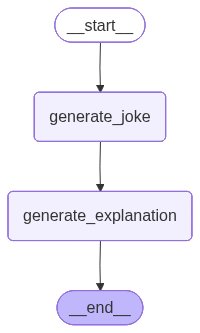

In [35]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow



In [36]:
config1 = {'configurable': {'thread_id':'1'}}
initial_state = {'topic': 'pizza'}
workflow.invoke(initial_state, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!',
 'explanation': 'This joke plays on the pun between "crusty" and "crusty," where "crusty" is a term used to describe someone or something that is grumpy or irritable, while "crusty" also refers to the outer crispy layer of a pizza crust. The joke suggests that the pizza went to the doctor because it was feeling grumpy or irritable, but in reality, it was just a play on words referring to the pizza crust being crusty.'}

In [38]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke plays on the pun between "crusty" and "crusty," where "crusty" is a term used to describe someone or something that is grumpy or irritable, while "crusty" also refers to the outer crispy layer of a pizza crust. The joke suggests that the pizza went to the doctor because it was feeling grumpy or irritable, but in reality, it was just a play on words referring to the pizza crust being crusty.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-f4ac-6ddd-8002-f518a2271460'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-21T06:07:13.006906+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-db56-6e12-8001-3f074496afab'}}, tasks=(), interrupts=())

In [39]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke plays on the pun between "crusty" and "crusty," where "crusty" is a term used to describe someone or something that is grumpy or irritable, while "crusty" also refers to the outer crispy layer of a pizza crust. The joke suggests that the pizza went to the doctor because it was feeling grumpy or irritable, but in reality, it was just a play on words referring to the pizza crust being crusty.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-f4ac-6ddd-8002-f518a2271460'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-21T06:07:13.006906+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-db56-6e12-8001-3f074496afab'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did t

In [40]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta go to the therapist? \nBecause it had too many emotional noodles to untangle!',
 'explanation': 'This joke plays on the idea of pasta having "emotional noodles" to untangle, which is a humorous way of saying that the pasta had a lot of emotional issues or problems to work through. It suggests that the pasta went to therapy (seeing a therapist) in order to get help with sorting through and resolving these emotional issues, just as a person might do. Overall, it\'s a playful and lighthearted way of imagining a humorous scenario involving food and therapy.'}

In [41]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke plays on the pun between "crusty" and "crusty," where "crusty" is a term used to describe someone or something that is grumpy or irritable, while "crusty" also refers to the outer crispy layer of a pizza crust. The joke suggests that the pizza went to the doctor because it was feeling grumpy or irritable, but in reality, it was just a play on words referring to the pizza crust being crusty.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-f4ac-6ddd-8002-f518a2271460'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-21T06:07:13.006906+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-db56-6e12-8001-3f074496afab'}}, tasks=(), interrupts=())

In [43]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke plays on the pun between "crusty" and "crusty," where "crusty" is a term used to describe someone or something that is grumpy or irritable, while "crusty" also refers to the outer crispy layer of a pizza crust. The joke suggests that the pizza went to the doctor because it was feeling grumpy or irritable, but in reality, it was just a play on words referring to the pizza crust being crusty.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-f4ac-6ddd-8002-f518a2271460'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-21T06:07:13.006906+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-db56-6e12-8001-3f074496afab'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did t

#   Time Travel

In [46]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f154db4-db56-6e12-8001-3f074496afab"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f154db4-db56-6e12-8001-3f074496afab'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-21T06:07:10.350265+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-ce96-664e-8000-bccec4cf297a'}}, tasks=(PregelTask(id='08b29f2f-4513-b4aa-0e0f-e1316b5dea11', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': 'This joke plays on the pun between "crusty" and "crusty," where "crusty" is a term used to describe someone or something that is grumpy or irritable, while "crusty" also refers to the outer crispy layer of a pizza crust. The joke suggests that the pizza went to the doctor because it was feeling grumpy or

In [47]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f154db4-db56-6e12-8001-3f074496afab"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!',
 'explanation': 'This joke is a play on words, as "crusty" can mean both having a rough or dry surface (like the crust of a pizza) and also not feeling well or sick. In this case, the pizza went to the doctor because it was feeling physically crusty due to its crust being dry or hard. It adds humor by personifying the pizza and putting it in a relatable situation of needing to see a doctor when not feeling well.'}

In [48]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke is a play on words, as "crusty" can mean both having a rough or dry surface (like the crust of a pizza) and also not feeling well or sick. In this case, the pizza went to the doctor because it was feeling physically crusty due to its crust being dry or hard. It adds humor by personifying the pizza and putting it in a relatable situation of needing to see a doctor when not feeling well.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db9-23b1-6a20-8003-d69284ecfcaa'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-21T06:09:05.311353+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db9-0f35-64c6-8002-1a7ac0823e65'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pi

#   Updating State

In [49]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f154db4-db56-6e12-8001-3f074496afab", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f154dba-fe7e-63f7-8002-4e0b5d2f9c01'}}

In [50]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154dba-fe7e-63f7-8002-4e0b5d2f9c01'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-05-21T06:09:55.097650+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154db4-db56-6e12-8001-3f074496afab'}}, tasks=(PregelTask(id='57df1ad1-6465-347e-e454-364d074d7b88', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke is a play on words, as "crusty" can mean both having a rough or dry surface (like the crust of a pizza) and also not f

In [51]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f154db4-db56-6e12-8001-3f074496afab"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!',
 'explanation': 'This joke is a play on words that humorously suggests that the pizza went to the doctor because it was feeling a little "crusty." In this context, "crusty" usually refers to someone or something that is irritable, grumpy, or generally in a bad mood. However, in the case of the pizza, it is interpreted literally as having a crust (the outer layer of the pizza). The joke is lighthearted and silly, as pizzas are not living beings that can feel emotions or physical sensations like humans do.'}

In [52]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little crusty!', 'explanation': 'This joke is a play on words that humorously suggests that the pizza went to the doctor because it was feeling a little "crusty." In this context, "crusty" usually refers to someone or something that is irritable, grumpy, or generally in a bad mood. However, in the case of the pizza, it is interpreted literally as having a crust (the outer layer of the pizza). The joke is lighthearted and silly, as pizzas are not living beings that can feel emotions or physical sensations like humans do.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154dbb-99da-67d4-8003-84b2def01b96'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-21T06:10:11.388370+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f154dbb-83d3-6393-8002-f31f6e0f7b9f'

# Fault Tolerence using persistence

In [25]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [26]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [27]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

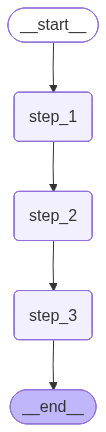

In [28]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [29]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f154d8d-7e97-6664-8001-26489fd8e01d'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-21T05:49:33.726663+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f154d8d-7e95-61b3-8000-e05796bd326e'}}, tasks=(PregelTask(id='ce3617ce-dc07-2f70-95e5-150b03b76c4a', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [ ]:
# 6. Re-run to show fault-tolerant resume - here None means I want to resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


KeyboardInterrupt: 

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f154d8d-7e97-6664-8001-26489fd8e01d'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-21T05:49:33.726663+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f154d8d-7e95-61b3-8000-e05796bd326e'}}, tasks=(PregelTask(id='ce3617ce-dc07-2f70-95e5-150b03b76c4a', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f154d8d-7e95-61b3-8000-e05796bd326e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-21T05:49:33.725727+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch